In [1]:
from TheCannon.surveys import apogee
from TheCannon import model, dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [2]:
tr_ID, wl, tr_flux, tr_ivar = apogee.load_spectra("example_DR10/Data")

Loading spectra from directory example_DR10/Data


Loading spectra: 548it [00:02, 207.89it/s]

Spectra loaded


In [3]:
tr_label = apogee.load_labels("example_DR10/reference_labels.csv")

Loading reference labels from file example_DR10/reference_labels.csv


In [4]:
print(tr_ID.shape)
print(wl.shape)
print(tr_flux.shape)
print(tr_label.shape)

(548,)
(8575,)
(548, 8575)
(548, 3)


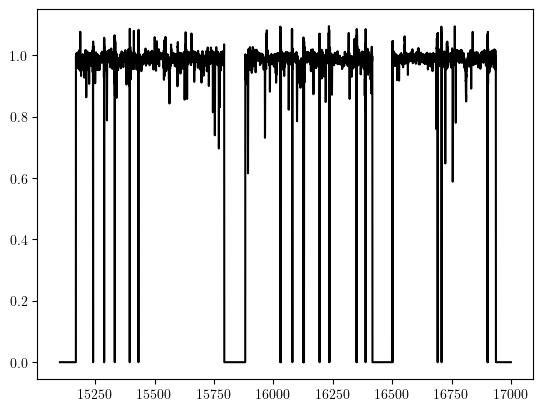

In [5]:
index = np.where(tr_ID=='2M21332216-0048247')[0][0]
flux = tr_flux[index]
plt.plot(wl, flux, c='k')
plt.show()

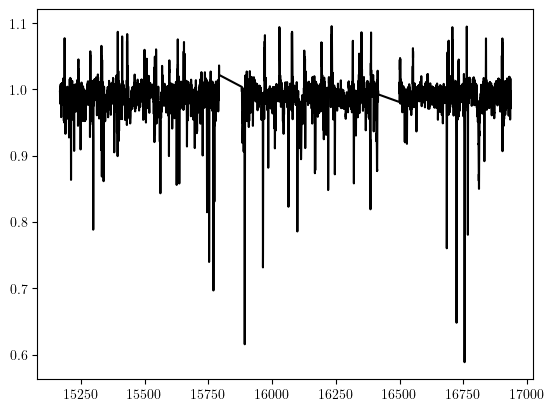

In [6]:
ivar = tr_ivar[index]
choose = ivar > 0
plt.plot(wl[choose], flux[choose], c='k')
plt.show()

In [7]:
test_ID = tr_ID
test_flux = tr_flux
test_ivar = tr_ivar

In [8]:
ds = dataset.Dataset(wl, tr_ID, tr_flux, tr_ivar, tr_label, test_ID, test_flux, test_ivar)

Loading dataset
This may take a while...


In [9]:
ds.set_label_names(['T_{eff}', '\log g', '[Fe/H]'])

Diagnostic for SNRs of reference and survey objects


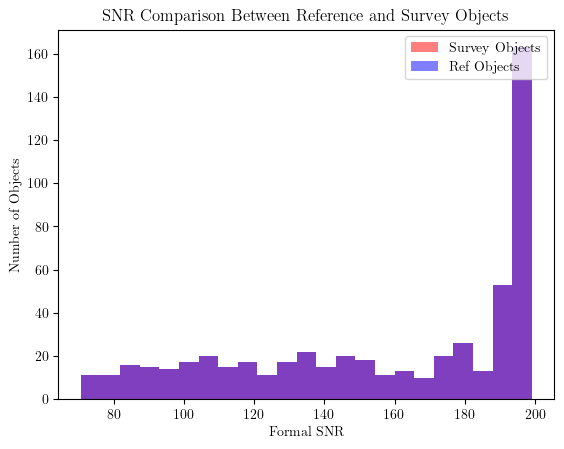

In [10]:
fig = ds.diagnostics_SNR()

Plotting every label against every other


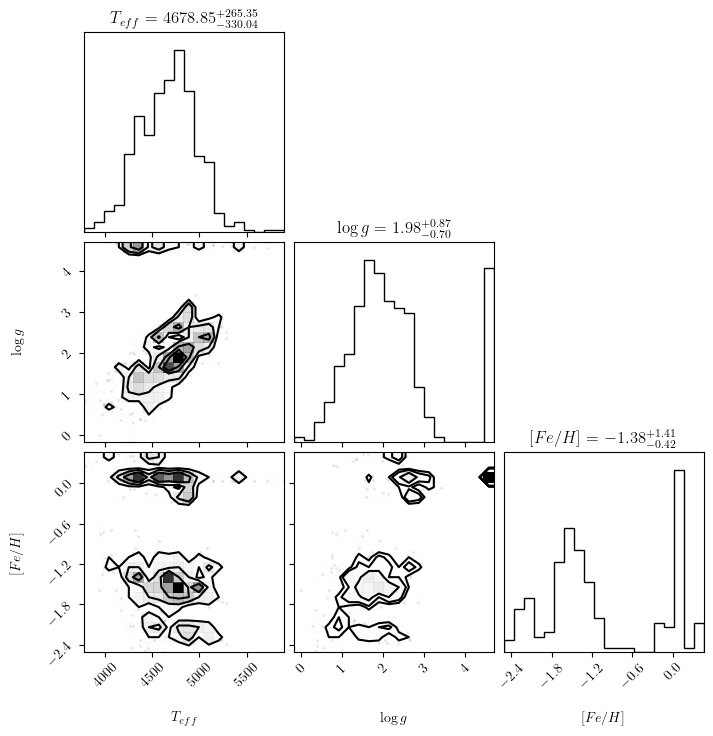

In [11]:
fig = ds.diagnostics_ref_labels()

In [12]:
ds.ranges = [[371,3192], [3697,5997], [6461,8255]]

In [13]:
pseudo_tr_flux, pseudo_tr_ivar = ds.continuum_normalize_training_q(q=0.90, delta_lambda=50, n_proc=8)

Continuum normalizing the tr set using running quantile...
Using 8 processes ... 


Running quantile: 100%|██████████| 6/6 [00:00<00:00, 28.74it/s]


In [14]:
contmask = ds.make_contmask(pseudo_tr_flux, pseudo_tr_ivar, frac=0.07)

Finding continuum pixels...
taking spectra in 3 regions
Target frac: 0.07
202 out of 2821 pixels identified as continuum
Cuts: f_cut 0.006000000000000003, sig_cut 0.006000000000000003
Target frac: 0.07
162 out of 2300 pixels identified as continuum
Cuts: f_cut 0.006900000000000005, sig_cut 0.006900000000000005
Target frac: 0.07
127 out of 1794 pixels identified as continuum
Cuts: f_cut 0.007000000000000005, sig_cut 0.007000000000000005
491 pixels returned as continuum


In [15]:
ds.ranges = [[371,3192], [3697,5500], [5500,5997], [6461,8255]]
contmask = ds.make_contmask(pseudo_tr_flux, pseudo_tr_ivar, frac=0.07)

Finding continuum pixels...
taking spectra in 4 regions
Target frac: 0.07
202 out of 2821 pixels identified as continuum
Cuts: f_cut 0.006000000000000003, sig_cut 0.006000000000000003
Target frac: 0.07
127 out of 1803 pixels identified as continuum
Cuts: f_cut 0.006000000000000003, sig_cut 0.006000000000000003
Target frac: 0.07
36 out of 497 pixels identified as continuum
Cuts: f_cut 0.010199999999999994, sig_cut 0.010199999999999994
Target frac: 0.07
127 out of 1794 pixels identified as continuum
Cuts: f_cut 0.007000000000000005, sig_cut 0.007000000000000005
492 pixels returned as continuum


In [16]:
ds.set_continuum(contmask)

In [17]:
cont = ds.fit_continuum(3, "sinusoid")

Fitting Continuum...
Fitting Continuum in 4 Regions...


Fitting continuum: 100%|██████████| 2/2 [00:00<00:00, 751.94it/s]


In [18]:
norm_tr_flux, norm_tr_ivar, norm_test_flux, norm_test_ivar = ds.continuum_normalize(cont)

taking spectra in 4 regions


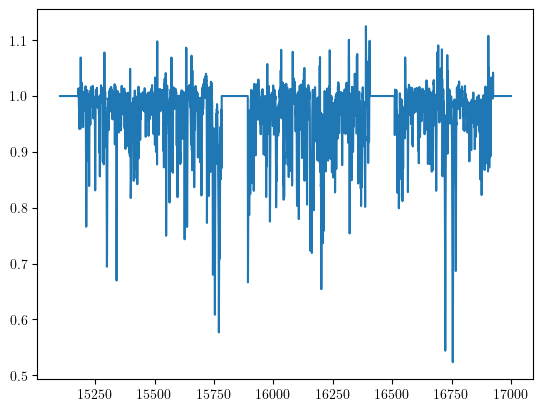

In [19]:
plt.plot(wl, norm_tr_flux[10,:])

In [20]:
ds.tr_flux = norm_tr_flux
ds.tr_ivar = norm_tr_ivar
ds.test_flux = norm_test_flux
ds.test_ivar = norm_test_ivar

In [21]:
md = model.CannonModel(2, useErrors=False)
md.fit(ds)

Training model: 100%|██████████| 18/18 [00:01<00:00, 10.96it/s]


In [22]:
md.diagnostics_contpix(ds)

Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_0.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_1.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_2.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_3.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_4.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_5.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_6.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_7.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_8.png
Diagnostic plot: fitted 0th order spec w/ cont pix
Saved as baseline_spec_with_cont_pix_9.png


In [23]:
label_errs = md.infer_labels(ds)

Inferring Labels (JAX)


Inferring labels: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]
